In [1]:
import numpy as np
import pandas as pd


Q:1-5
You are given three quater files, your job is to append these three files and make a single dataframe.
Have a index as Q-1 Q-2 Q-3 for respective quater files in the dataframe
Your are given a file items.csv which has item_id and item_name. Find out most sold items in each quarter.
Find out items which has made most revenue in each quarter.
Find out avg order price of each quarter.
Note: item_price is given as str with $ sign, in earlier task you have converted this to rupees, here too first convert item_price field in rupees.

In [69]:
q1=pd.read_csv('quarter-1.csv')
q2=pd.read_csv('quarter-2.csv')
q3=pd.read_csv('quarter-3.csv')
items=pd.read_csv('items.csv')

total_data=pd.concat([q1,q2,q3],keys=['Q1','Q2','Q3']).reset_index()

total_data.merge(items,on='item_id').groupby(['level_0','item_name'])['item_id'].count().sort_values(ascending=False).reset_index().drop_duplicates(subset=['level_0'],keep='first')

total_data['item_price']=total_data['item_price'].str.replace('$',"").astype(float)
total_data.merge(items,on='item_id').groupby(['level_0','item_name'])['item_price'].sum().sort_values(ascending=False).reset_index().drop_duplicates(subset='level_0',keep='first')

total_data.groupby('level_0')['item_price'].mean()
total_data


,level_0,level_1,order_id,quantity,item_id,choice_description_id,item_price
0,Q1,0,1,1,1,1,3.39
1,Q1,1,1,1,2,2,3.39
2,Q1,2,2,2,4,3,16.98
3,Q1,3,4,1,7,6,9.25
4,Q1,4,6,1,9,8,8.75
...,...,...,...,...,...,...,...
4617,Q2,2342,1829,1,23,92,11.25
4618,Q2,2343,1830,1,23,1043,11.25
4619,Q2,2344,1832,1,10,116,8.75
4620,Q2,2345,1832,1,8,0,4.45


In [ ]:
matches=pd.read_csv('IPL_Matches_2008_2022.csv')
deliveries=pd.read_csv('ipl_deliveries.csv')

,ID,Team,innings,overs,ballnumber,batter,bowler,non-striker,extra_type,batsman_run,extras_run,total_run,non_boundary,isWicketDelivery,player_out,kind,fielders_involved,BattingTeam,BowlingTeam
0,1312200,Rajasthan RoyalsGujarat Titans,1,0,1,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
1,1312200,Rajasthan RoyalsGujarat Titans,1,0,2,YBK Jaiswal,Mohammed Shami,JC Buttler,legbyes,0,1,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
2,1312200,Rajasthan RoyalsGujarat Titans,1,0,3,JC Buttler,Mohammed Shami,YBK Jaiswal,NaN,1,0,1,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
3,1312200,Rajasthan RoyalsGujarat Titans,1,0,4,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
4,1312200,Rajasthan RoyalsGujarat Titans,1,0,5,YBK Jaiswal,Mohammed Shami,JC Buttler,NaN,0,0,0,0,0,NaN,NaN,NaN,Rajasthan Royals,Gujarat Titans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225949,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,5,P Kumar,I Sharma,SB Joshi,legbyes,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225950,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,6,SB Joshi,I Sharma,P Kumar,NaN,1,0,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225951,335982,Royal Challengers BangaloreKolkata Knight Riders,2,14,7,P Kumar,I Sharma,SB Joshi,NaN,0,0,0,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders
225952,335982,Royal Challengers BangaloreKolkata Knight Riders,2,15,1,SB Joshi,LR Shukla,P Kumar,wides,0,1,1,0,0,NaN,NaN,NaN,Royal Challengers Bangalore,Kolkata Knight Riders


Q-6 From the IPL wala dataset you have to find the Purple cap holder each season.
Note: Bowler with most no wickets in a season gets purple cap. If more than one bowler have same no of wickets in the season, one with least ecomnomy among them is purple cap holder.

Bowler's Economy = runs-conceded per six balls

In [ ]:
full_df=deliveries.merge(matches,on='ID')

bowler_states=full_df.groupby(['Season','bowler']).agg(
    Total_wickets=('isWicketDelivery','sum'),
    Total_runs=('total_run','sum'),
    Total_balls=('ballnumber','count')
).reset_index()
bowler_states['Economy']=(bowler_states['Total_runs']/bowler_states['Total_balls'])*6
bowler_states.sort_values(['Total_wickets','Economy'],ascending=[False,True]).drop_duplicates(subset='Season',keep='first').sort_values(by='Season')


,Season,bowler,Total_wickets,Total_runs,Total_balls,Economy
84,2007/08,Sohail Tanvir,24,275,265,6.226415
174,2009,RP Singh,26,430,382,6.753927
284,2009/10,PP Ojha,22,439,360,7.316667
447,2011,SL Malinga,30,393,397,5.939547
537,2012,M Morkel,30,466,389,7.187661
629,2013,DJ Bravo,34,505,392,7.729592
779,2014,MM Sharma,26,457,324,8.462963
847,2015,DJ Bravo,28,442,324,8.185185
938,2016,B Kumar,24,503,414,7.289855
1048,2017,B Kumar,28,384,324,7.111111


Q-7: Best bowler in death overs.
Note: Have taken most no of wickets in case of tie with least economy

Death Overs - [16-20]

In [133]:
only_death_overs=deliveries[deliveries['overs']>15]
bowler_states_in_death_overs=only_death_overs.groupby('bowler').agg(
    Total_wickets=('isWicketDelivery','sum'),
    Total_runs=('total_run','sum'),
    Total_balls=('ballnumber','count')
).reset_index()

bowler_states_in_death_overs['Economy']=(bowler_states_in_death_overs['Total_runs']/bowler_states_in_death_overs['Total_balls'])*6
bowler_states_in_death_overs.sort_values(by=['Total_wickets','Economy'],ascending=[False,True]).head(10)

,bowler,Total_wickets,Total_runs,Total_balls,Economy
85,DJ Bravo,115,1842,1179,9.374046
308,SL Malinga,104,1252,965,7.784456
50,B Kumar,82,1575,1048,9.017176
138,JJ Bumrah,79,1508,1072,8.440299
315,SP Narine,64,942,717,7.882845
67,CH Morris,61,862,609,8.492611
217,Mohammed Shami,61,885,501,10.598802
261,R Vinay Kumar,58,1022,598,10.254181
7,A Nehra,54,633,434,8.751152
347,UT Yadav,54,1100,635,10.393701


Q-8 Batsman record season wise
Make a function which takes a input batsman_name and it returns a dataframe. Columns of the data frame are - ['Season','Innings', 'TotalRuns', 'Avg', 'HighestScore','StrikeRate'].

In result make Season column as index.

Avg - total_runs/ no of time got out. - player_out column will help.

StrikeRate -(total_runs/ balls faced) * 100- wides are not included in batsman ball faced counts. No balls are included. -> Extra_type column will help

Batsman Can score runs on No Balls.

Batsman can get out on No Ball or Wides. And even while being on non-striker. Keep these things in mind before masking.

In [209]:
def make_new_df(batsman_name):
    full_df=deliveries.merge(matches,on='ID')

    batter_df=full_df[full_df['batter']==batsman_name]

    
    out_df=full_df[full_df['player_out']==batsman_name]

    valid_balls=batter_df[batter_df['extra_type']!='wides']

    total_runs=batter_df.groupby('Season')['total_run'].sum()
    total_balls=valid_balls.groupby('Season')['ballnumber'].count()
    innings=batter_df.groupby('Season')['ID'].nunique()
    out=out_df.groupby('Season')['player_out'].count()
    highest_score=batter_df.groupby(['Season','ID'])['total_run'].sum().reset_index().sort_values(by='total_run',ascending=False).drop_duplicates(subset='Season',keep='first').sort_values(by='Season').set_index('Season').drop(columns='ID').squeeze()

    new_df=pd.DataFrame({
        'Innings':innings,
        'Total_Runs':total_runs,
        'Total_Balls':total_balls,
        'Highest_Score':highest_score
    })

    new_df['Avg']=new_df['Total_Runs']/out
    new_df['StrikeRate']=(new_df['Total_Runs']/new_df['Total_Balls'])*100
    new_df.drop(columns='Total_Balls',inplace=True)

    return new_df

make_new_df('V Kohli')

,Innings,Total_Runs,Highest_Score,Avg,StrikeRate
Season,,,,,
2007/08,12,187,40,17.000000,119.108280
2009,13,258,53,23.454545,117.808219
2009/10,13,320,64,29.090909,150.943396
2011,16,584,74,48.666667,126.956522
2012,15,375,76,28.846154,115.030675
2013,16,660,101,47.142857,143.790850
2014,14,373,77,28.692308,126.870748
2015,16,519,83,47.181818,134.455959
2016,16,998,116,83.166667,155.937500


Q-9 Using both dataset, make a dataframe as described below
Data Frame columns-> ['PlayerOfThematch', 'BattingFigure', 'BowlingFigure']

BattingFigure-><runs>/<balls>
BowlingFigure-><wicket>/<runs-conceded>
DataFrame should have one record for each match.

Say 'V Kohli' got POM award then in dataset include his batting figure of that match. Say he scored 112runs in 76 balls. And he hasn't bowled so Bowling Figure will be NaN

PlayerOfThematch BattingFigure BowlingFigure
V Kohli          112/76         nan  

In [252]:
full_df=deliveries.merge(matches,on='ID')

batter=full_df[full_df['batter']==full_df['Player_of_Match']]

Player=batter.groupby(['ID','Player_of_Match']).agg(
    Runs=('total_run','sum'),
    Balls=('ballnumber','count')
).reset_index()

Player['BattingFigure']=Player['Runs'].astype(str)+ "/" + Player['Balls'].astype(str)
Player=Player[['ID','Player_of_Match','BattingFigure']]

bowler=full_df[full_df['bowler']==full_df['Player_of_Match']]

bowler=bowler.groupby(['ID','Player_of_Match']).agg(
    Wickets=('isWicketDelivery','sum'),
    Runs_conceded=('total_run','sum')
).reset_index()

bowler['BowlingFigure'] = bowler['Wickets'].astype(str) + '/' + bowler['Runs_conceded'].astype(str)

bowler = bowler[['ID', 'Player_of_Match', 'BowlingFigure']]

final_table=matches[['ID','Player_of_Match']].drop_duplicates()
final_table=final_table.merge(Player,on=['ID','Player_of_Match'],how='left')
final_table=final_table.merge(bowler,on=['ID','Player_of_Match'],how='left').drop(columns='ID')
final_table

,Player_of_Match,BattingFigure,BowlingFigure
0,HH Pandya,36/32,3/18
1,JC Buttler,106/60,NaN
2,RM Patidar,114/55,NaN
3,DA Miller,70/38,NaN
4,Harpreet Brar,NaN,3/26
...,...,...,...
945,DJ Hussey,45/45,1/35
946,MV Boucher,40/20,NaN
947,MF Maharoof,NaN,2/14
948,MEK Hussey,117/54,NaN


In [253]:
sepal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vT58ekmHTwptX7Bs4QOy6YByA1HMvYTACeeIjrKhHE0Pg1K_3egewHMKMh02zN9D5-yHVXfvuaa3s5u/pub?gid=2028782809&single=true&output=csv")
petal_all = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vQinLXShrOz4ExNaW1bSQVuvbbhIzJW7G0kkkD2SvqSD6STjLrQQiftgI7BGe10sBZi0CNr2_sJpQAz/pub?gid=1580010789&single=true&output=csv")

virginica = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSK39MwduGPHYNgw5yViezoLYCVDKMCWIHzjnt3GZNaxHPFOQLr2q6no_tyqTsOk-VfXleslfGVe9eJ/pub?gid=314231613&single=true&output=csv")
versicolor = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vTcSFgLnabqIrgIc5WlwvnbbvyyJsgZjR-0E0-4TR-5aHgv_0EP6yNWglkkls3AXM2qHCR5VYzWCoTM/pub?gid=715607857&single=true&output=csv")
setosa = pd.read_csv("https://docs.google.com/spreadsheets/d/e/2PACX-1vSjqJpdgy2X_oDUUqQ0sSaFKqnnf8MYU4KgJSYgHaHmq0Wb1weMOsJXh-rICHmkLcaTkOwzMYLeh959/pub?gid=2003684803&single=true&output=csv")

<Axes: >

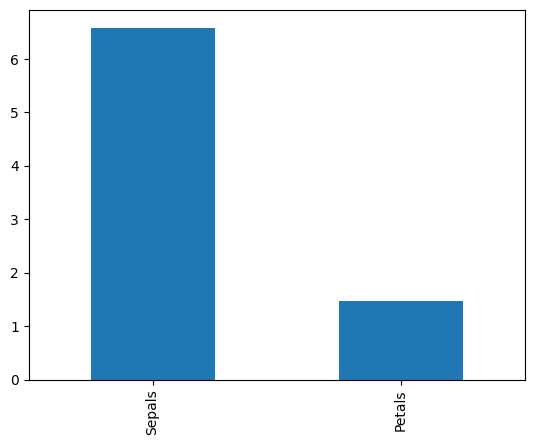

In [303]:

avg_sepal_length=sepal_all.merge(virginica,on='Id').groupby('Species')['SepalLengthCm'].mean()
avg_petal_length=petal_all.merge(setosa,on='Id').groupby('Species')['PetalLengthCm'].mean()

combine=pd.Series({
    'Sepals':avg_sepal_length.iloc[0],
    'Petals':avg_petal_length.iloc[0]
})

combine.plot(kind='bar')



Q-10: Create the complete dataset by uisng the below datasets:
virginica
versicolor
setosa
sepal all
petal all
This dataset should have these below column names in order:

Id
Species
SepalLengthCm
SepalWidthCm
PetalLengthCm
PetalWidthCm
Also, the dataset should be shuffled means the Id column should not be in increasing or decreasing order. So, make a dataset which has the shuffled Id column. You can use DataFrame.sample() method to shuffle.

In [379]:
concated=pd.concat([virginica,versicolor,setosa],ignore_index=True)
total_data_df=concated.merge(sepal_all,on='Id').merge(petal_all,on='Id').drop(columns=['Unnamed: 0_x','Unnamed: 0_y','Unnamed: 0'])
shuffled_df=total_data_df.sample(frac=1)
shuffled_df

,Id,Species,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
89,90,Iris-versicolor,5.5,2.5,4.0,1.3
55,56,Iris-versicolor,5.7,2.8,4.5,1.3
66,67,Iris-versicolor,5.6,3.0,4.5,1.5
48,149,Iris-virginica,6.2,3.4,5.4,2.3
129,30,Iris-setosa,4.7,3.2,1.6,0.2
...,...,...,...,...,...,...
123,24,Iris-setosa,5.1,3.3,1.7,0.5
115,16,Iris-setosa,5.7,4.4,1.5,0.4
61,62,Iris-versicolor,5.9,3.0,4.2,1.5
122,23,Iris-setosa,4.6,3.6,1.0,0.2


Q-11: Find out the maximum and minimum sepal width and petal width of Setosa and Versicolor. To do this:
First create a dataset with merging the required datasets
After that, use groupby to create groups based on the "Species" column.
Then find out which are asked in this question.

The output should be like this:

Minimum Sepal width of Setosa is 2.3
Maximum Sepal width of Setosa is 4.4

**************************************************

Minimum Sepal width of Versicolor is 2.0
Maximum Sepal width of Versicolor is 3.4

**************************************************

In [ ]:
set_ver=pd.concat([setosa,versicolor],ignore_index=True)
combined_set_ver=set_ver.merge(sepal_all,on='Id').merge(petal_all,on='Id').drop(columns=['Unnamed: 0_x','Unnamed: 0_y','Unnamed: 0'])
total_min_max=combined_set_ver.groupby('Species').agg({
    'SepalWidthCm':['max','min'],
    'PetalWidthCm':['max','min']
})

max_setosa = total_min_max.loc['Iris-setosa', ('SepalWidthCm', 'max')]
min_setosa = total_min_max.loc['Iris-setosa', ('SepalWidthCm', 'min')]

max_versi=total_min_max.loc['Iris-versicolor', ('SepalWidthCm', 'max')]
min_versi=total_min_max.loc['Iris-versicolor', ('SepalWidthCm', 'min')]

print("Minimum Sepal width of Setosa is {}".format(min_setosa))
print("Maximium Sepal width of Setosa is {}".format(max_setosa),end="\n\n")
print("**************************************************")
print('Minimum Sepal width of Versicolor is {}'.format(min_versi))
print("Maximium Sepal width of Versicolor is {}".format(max_versi),end="\n\n")
print("**************************************************")

Minimum Sepal width of Setosa is 2.3
Maximium Sepal width of Setosa is 4.4

**************************************************
Minimum Sepal width of Versicolor is 2.0
Maximium Sepal width of Versicolor is 3.4

**************************************************
